## Simple Sequential Flow

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class State(TypedDict):
    concept: str
    detailed_plan : str

In [3]:
def generator_node(state: State) -> State:
    return {
        "concept": "some concept"}

def refiner_node(state: State) -> State:
    plan = f"Plan for {state['concept']}.Step 1: Design panels. Step 2: Build boiler."
    return {
        "detailed_plan": plan
    }


builder = StateGraph(State)

builder.add_node("gen", generator_node)
builder.add_node("refine", refiner_node)

builder.add_edge(START, "gen")
builder.add_edge("gen", "refine")
builder.add_edge("refine", END)

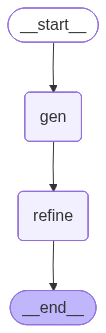

In [5]:
builder.compile()

## Sequential Flow with Prompt Chaining

In [6]:
from langchain_ollama import ChatOllama

In [8]:
llm = ChatOllama(model="qwen2.5-coder:7b", temperature = 0)

class SEOSTATE(TypedDict):
    topic: str
    keyword: str
    meta_description: str

In [9]:
def strategy_node(state: SEOSTATE) -> SEOSTATE:
    prompt = f"You are an SEO strategist. Given the topic {state['topic']}, generate a single best SEO keyword."
    response = llm.invoke(prompt)
    return {
        "keyword": response.content.strip()
    }

def writer_node(state: SEOSTATE) -> SEOSTATE:
    prompt = f"You are an SEO writer. Given the keyword {state['keyword']}, generate a meta description."
    response = llm.invoke(prompt)
    return {
        "meta_description": response.content.strip()
    }

In [10]:
seo_builder = StateGraph(SEOSTATE)

seo_builder.add_node("Strategist", strategy_node)
seo_builder.add_node("Writer", writer_node)

seo_builder.add_edge(START, "Strategist")
seo_builder.add_edge("Strategist", "Writer")
seo_builder.add_edge("Writer", END)

seo_app = seo_builder.compile()

In [12]:
output = seo_app.invoke({"topic": "Agentic AI in 2026"})
print(f"Keyword: {output['keyword']}")
print(f"Meta Description: {output['meta_description']}")

Keyword: "Agentic AI 2026 Trends and Applications"
Meta Description: "Discover the future of Agentic AI in 2026! Explore emerging trends, innovative applications, and how this technology is reshaping industries worldwide. Stay ahead with our comprehensive guide on what to expect from Agentic AI by 2026."
